In [ ]:
import numpy as np
import pyccl as ccl
import matplotlib.pyplot as plt
from core import cosmo, P_e, load_bispectrum, P_e_array, build_bispectrum_grid


B_interp, data = load_bispectrum("bispectrum_grid.npz")
k_grid = data["k_grid"]
print(data.keys())


KeysView(NpzFile 'bispectrum_grid.npz' with keys: B_grid, k_grid, a_grid, phi_grid)


(20, 50, 50, 40)
(20,)
(50,)
(40,)
0.012116971403490245
[1.00000000e-03 1.20679264e-03 1.45634848e-03 1.75751062e-03
 2.12095089e-03 2.55954792e-03 3.08884360e-03 3.72759372e-03
 4.49843267e-03 5.42867544e-03 6.55128557e-03 7.90604321e-03
 9.54095476e-03 1.15139540e-02 1.38949549e-02 1.67683294e-02
 2.02358965e-02 2.44205309e-02 2.94705170e-02 3.55648031e-02
 4.29193426e-02 5.17947468e-02 6.25055193e-02 7.54312006e-02
 9.10298178e-02 1.09854114e-01 1.32571137e-01 1.59985872e-01
 1.93069773e-01 2.32995181e-01 2.81176870e-01 3.39322177e-01
 4.09491506e-01 4.94171336e-01 5.96362332e-01 7.19685673e-01
 8.68511374e-01 1.04811313e+00 1.26485522e+00 1.52641797e+00
 1.84206997e+00 2.22299648e+00 2.68269580e+00 3.23745754e+00
 3.90693994e+00 4.71486636e+00 5.68986603e+00 6.86648845e+00
 8.28642773e+00 1.00000000e+01]


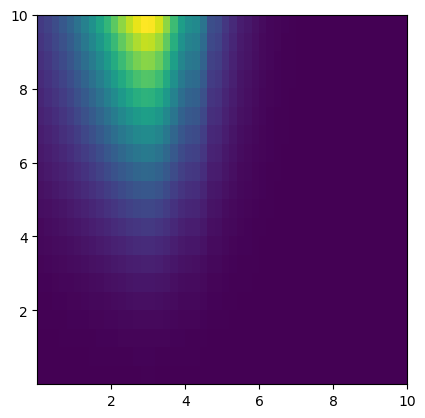

In [2]:
print(data['B_grid'].shape)
print(data['a_grid'].shape)
print(data['k_grid'].shape)
print(data['phi_grid'].shape)

print(np.min(data['B_grid']))

print(data['k_grid'])
plt.imshow(data['B_grid'][:, :, 0, 0], extent=(k_grid[0], k_grid[-1], k_grid[0], k_grid[-1]), origin='lower')


[18.35300488 18.35300488 18.35300488 ... -4.36322933 -4.36322933
 -4.36322933]


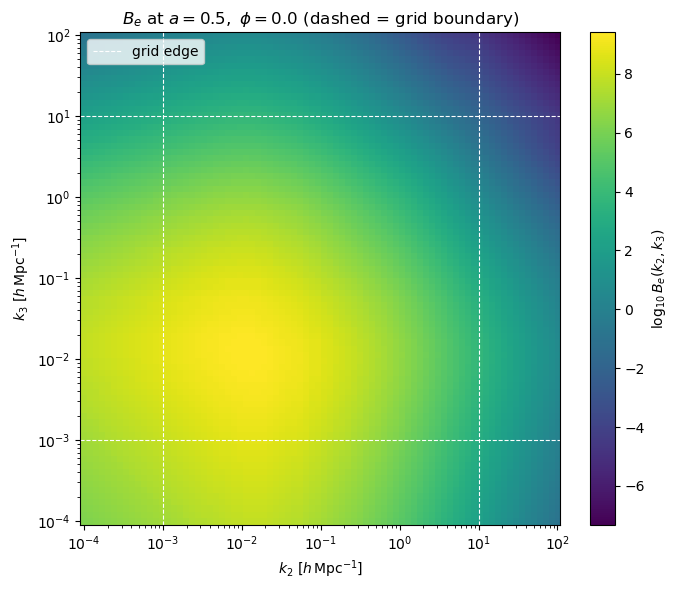

In [3]:
# Evaluate B_interp on a new k grid that extends beyond the precomputed range
# (k_grid spans 1e-3 to 1e1) to exercise the log-linear extrapolation.
k_new = np.logspace(-4, 2, 80)   # one decade beyond each edge
a_val = 0.5
phi_val = 0.0

k2_2d, k3_2d = np.meshgrid(k_new, k_new, indexing='ij')
N = k2_2d.size

pts = np.column_stack([
    np.full(N, a_val),
    k2_2d.ravel(),
    k3_2d.ravel(),
    np.full(N, phi_val),
])
B_2d = B_interp(pts).reshape(k2_2d.shape)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.pcolormesh(
    k_new, k_new, np.log10(B_2d),
    shading='auto', cmap='viridis'
)
plt.colorbar(im, ax=ax, label=r'$\log_{10} B_e(k_2, k_3)$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.axvline(data['k_grid'][0],  color='w', ls='--', lw=0.8, label='grid edge')
ax.axvline(data['k_grid'][-1], color='w', ls='--', lw=0.8)
ax.axhline(data['k_grid'][0],  color='w', ls='--', lw=0.8)
ax.axhline(data['k_grid'][-1], color='w', ls='--', lw=0.8)
ax.set_xlabel(r'$k_2\ [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$k_3\ [h\,\mathrm{Mpc}^{-1}]$')
ax.set_title(rf'$B_e$ at $a={a_val},\ \phi={phi_val}$ (dashed = grid boundary)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()




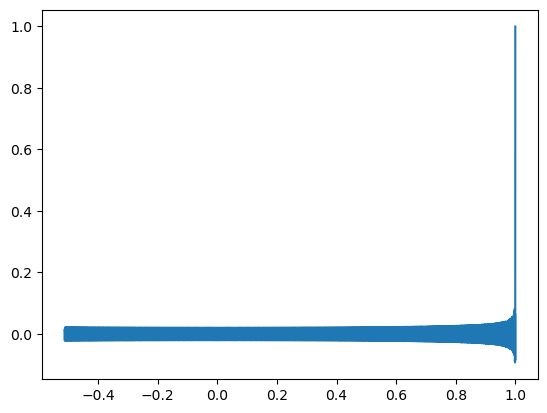

In [ ]:
from scipy.special import spherical_jn, eval_legendre, jv

mu = np.linspace(-1, 1, 10000)
y = eval_legendre(1500, mu)
plt.plot(mu, y)